# Laboratorio 3.2 - Amazon SageMaker: Exploración de datos (EDA)

**Nombre completo:** Richard Santiago Caicedo Toro

## Objetivo
Realizar un Análisis Exploratorio de Datos (EDA) sobre el dataset importado en el
Laboratorio 3.1, identificando su estructura, calidad (valores nulos, duplicados,
outliers) y patrones relevantes mediante estadísticas y visualizaciones.

## Explicación de la tarea
Se cargan los datos, se calculan estadísticas descriptivas, se identifican problemas de
calidad (nulos, duplicados, outliers) y se generan visualizaciones (histogramas, boxplots,
matriz de correlación) para comprender mejor la distribución y las relaciones entre
variables.


## 1. Importar librerías

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


## 2. Cargar el dataset (mismo origen que en el Lab 3.1)

In [2]:
data_path = Path("data/dataset.csv")
if not data_path.exists():
    data_path = Path("../data/dataset.csv")

if not data_path.exists():
    raise FileNotFoundError("No se encontró data/dataset.csv ni ../data/dataset.csv")

df = pd.read_csv(data_path)
print(f"Dataset cargado desde: {data_path}")
df.head()


Dataset cargado desde: ..\data\dataset.csv


,student_id,age,city,study_hours,attendance,performance_level,final_score
0,1,20,Bogota,8.0,92.0,alto,4.6
1,2,21,Medellin,5.0,85.0,medio,3.8
2,3,19,Cali,3.0,72.0,bajo,2.9
3,4,22,Bogota,7.0,88.0,medio,4.1
4,5,20,Cartagena,2.0,65.0,bajo,2.5


## 3. Estadísticas descriptivas

In [3]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,15.0,NaN,NaN,NaN,7.8,4.195235,1.0,4.5,8.0,11.5,14.0
age,15.0,NaN,NaN,NaN,21.066667,1.486447,19.0,20.0,21.0,22.0,24.0
city,15,4,Bogota,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours,14.0,NaN,NaN,NaN,5.428571,2.408775,1.0,4.0,5.5,7.0,9.0
attendance,14.0,NaN,NaN,NaN,83.071429,11.076408,59.0,78.75,86.0,91.5,96.0
performance_level,15,3,medio,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
final_score,15.0,NaN,NaN,NaN,3.753333,0.796301,2.1,3.3,3.9,4.4,4.8


## 4. Calidad de los datos: valores nulos y duplicados

In [4]:
nulos = df.isnull().sum().sort_values(ascending=False)
porcentaje_nulos = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "% nulos": porcentaje_nulos})


,nulos,% nulos
study_hours,1,6.67
attendance,1,6.67
student_id,0,0.00
city,0,0.00
age,0,0.00
performance_level,0,0.00
final_score,0,0.00


In [ ]:
print("Filas duplicadas:", df.duplicated().sum())


## 5. Limpieza básica de datos

In [6]:
# Eliminar duplicados e imputar nulos según el tipo de variable.
df_limpio = df.drop_duplicates().copy()

for col in df_limpio.select_dtypes(include=np.number).columns:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

for col in df_limpio.select_dtypes(include="str").columns:
    if df_limpio[col].isnull().any():
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mode()[0])

print("Nulos restantes:", df_limpio.isnull().sum().sum())
print("Dimensiones tras limpieza:", df_limpio.shape)


Nulos restantes: 0
Dimensiones tras limpieza: (14, 7)


## 6. Visualización de variables numéricas

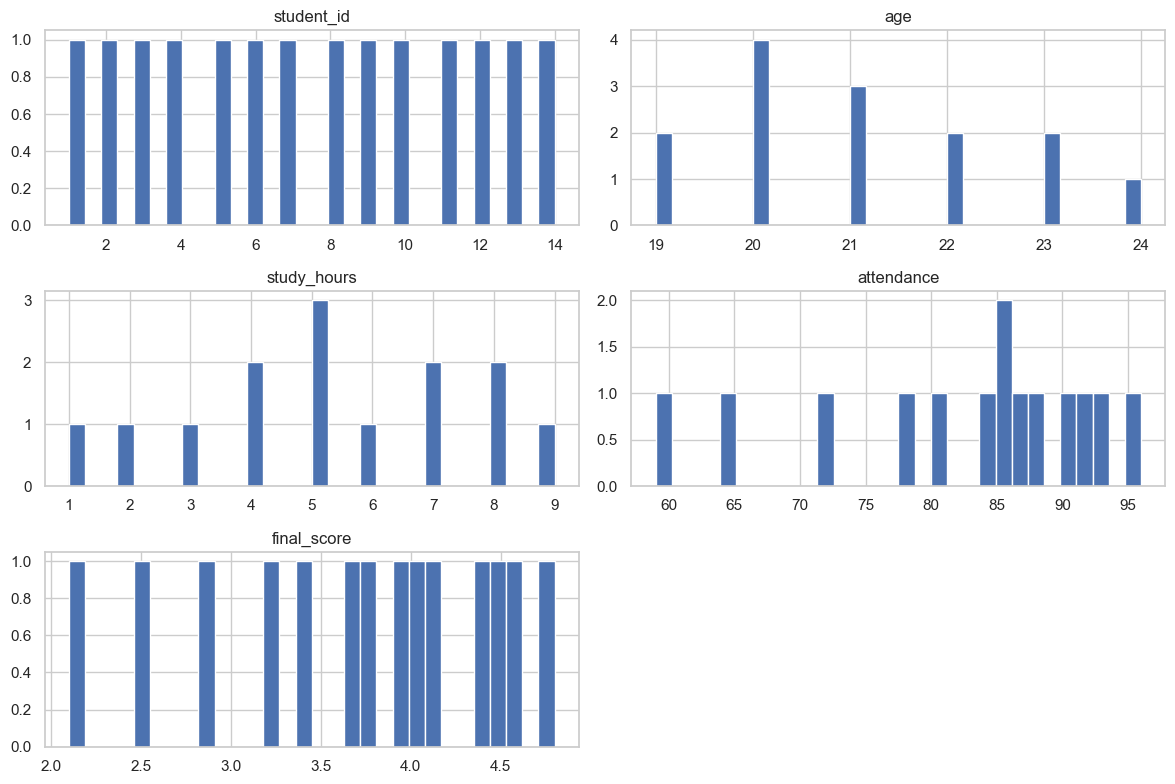

In [7]:
num_cols = df_limpio.select_dtypes(include=np.number).columns

df_limpio[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


## 7. Detección de outliers (boxplots)

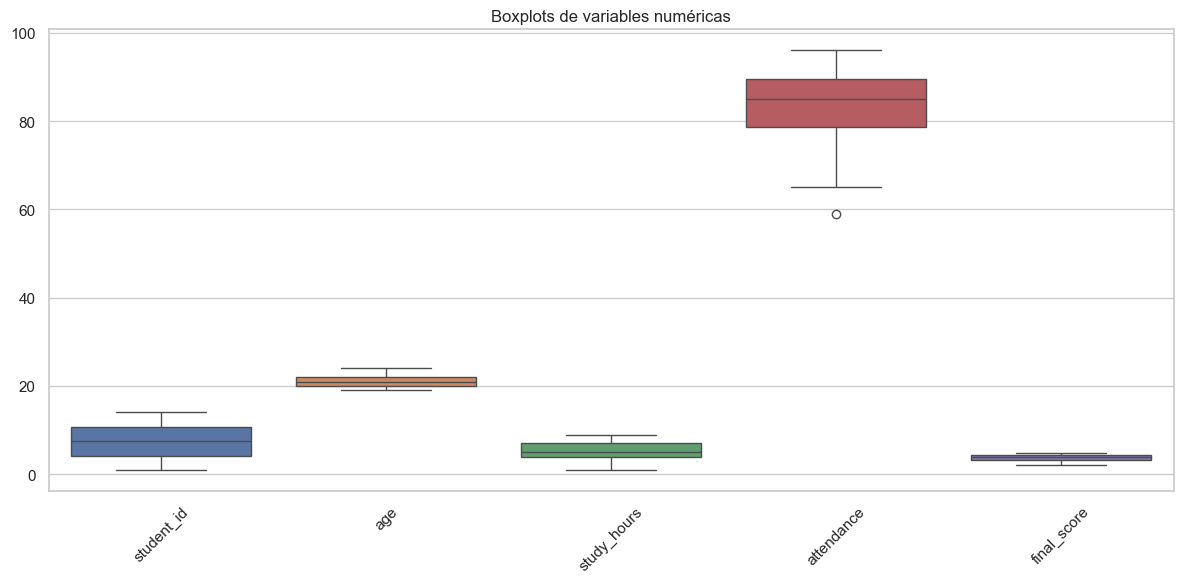

In [8]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_limpio[num_cols])
plt.xticks(rotation=45)
plt.title("Boxplots de variables numéricas")
plt.tight_layout()
plt.show()


## 8. Matriz de correlación

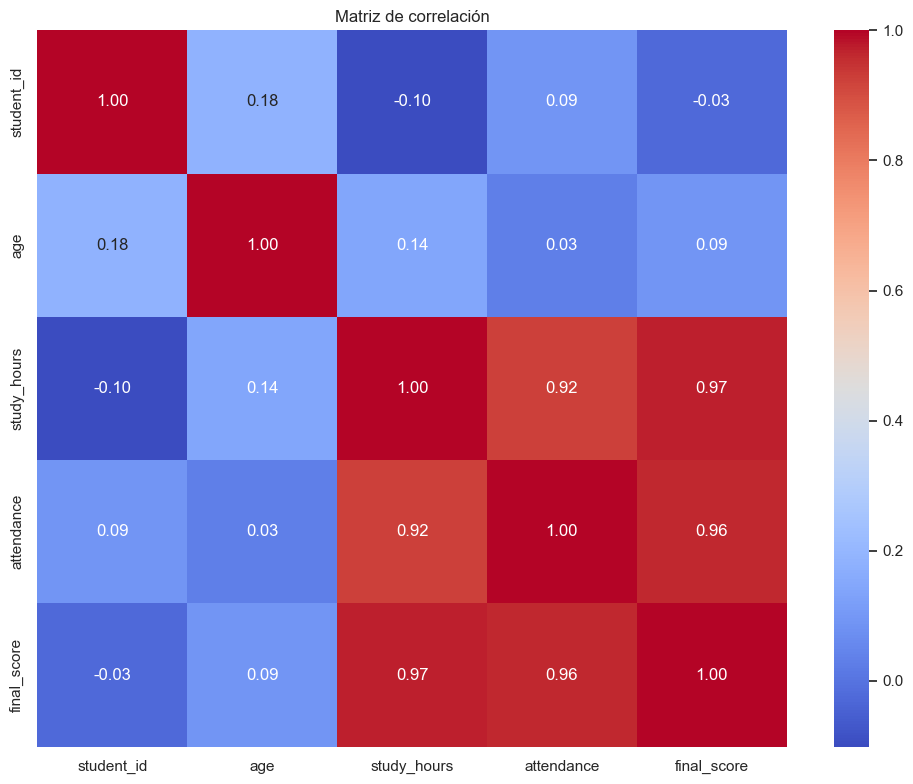

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_limpio[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()
